In [1]:
import numpy as np
import pandas as pd

from tabularepimdl.SimpleTransition_Vec_Encode import SimpleTransition_Vec_Encode

from tabularepimdl.MultiStrainInfectiousProcess_Vec_Encode import MultiStrainInfectiousProcess_Vec_Encode
from tabularepimdl.HospRule_Vec_Encode import HospRule_Vec_Encode

from tabularepimdl.EpiModel_Vec_Encode1_2 import EpiModel_Vec_Encode_1_2

import plotly.express as px
import plotly.graph_objects as go

In [2]:
infstate_compartments = ['S', 'I', 'R']
simpletrans_column_compartments =  ['S', 'I', 'R']
multistrain_columns_all_categories = ['S', 'I', 'R']

#define immunity such tht "adjacent" strains have 50% cross protection and "non-adjacent" strains have 20% cross protection.
cp_matrix = np.array([[1.0, 0.5, 0.2],
                      [0.5, 1.0, 0.5],
                      [0.2, 0.5, 1.0]])

In [3]:
three_strain_infect_vec = MultiStrainInfectiousProcess_Vec_Encode(betas=np.array([0.5, 0.75, 1]), columns=["Strain1", "Strain2", "Strain3"], cross_protect=cp_matrix, columns_all_categories = multistrain_columns_all_categories, infstate_compartments=infstate_compartments)

In [4]:
recover_rule1_vec = SimpleTransition_Vec_Encode(column='Strain1', from_st='I', to_st='R', rate=0.2, infstate_compartments=infstate_compartments, column_categories=simpletrans_column_compartments)
recover_rule2_vec = SimpleTransition_Vec_Encode(column='Strain2', from_st='I', to_st='R', rate=0.2, infstate_compartments=infstate_compartments, column_categories=simpletrans_column_compartments)
recover_rule3_vec = SimpleTransition_Vec_Encode(column='Strain3', from_st='I', to_st='R', rate=0.2, infstate_compartments=infstate_compartments, column_categories=simpletrans_column_compartments)

In [5]:
pop_3strain_hosp_large = pd.DataFrame(
    {
        "Strain1": pd.Categorical(['S','I'], categories=['S','I','R']),
        "Strain2": pd.Categorical(['S','S'], categories=['S','I','R']),
        "Strain3": pd.Categorical(['S','S'], categories=['S','I','R']),
        "Hosp1": "U",
        "Hosp2": "U",
        "Hosp3": "U",
        "N": np.array([9999,1]),
        "T":0
    }
)

In [6]:
strain_cols = ["Strain1","Strain2","Strain3"]
hosp_cols= ["Hosp1","Hosp2","Hosp3"]
inf_cols_categories = ['S', 'I', 'R']
hosp_cols_categories = ['U', 'H']
prim_hrate = 0.05
sec_hrate = 0.01
stochastic = False

hosp_rule_vec = HospRule_Vec_Encode(strain_cols = strain_cols, hosp_cols=hosp_cols, 
                                strain_cols_all_categories = inf_cols_categories,
                                hosp_cols_all_categories = hosp_cols_categories,
                                prim_hrate = prim_hrate, sec_hrate = sec_hrate)

In [7]:
SIR_3Strain_hosp_vec =  EpiModel_Vec_Encode_1_2(init_state=pop_3strain_hosp_large, rules = [
    [three_strain_infect_vec, recover_rule1_vec, recover_rule2_vec, recover_rule3_vec],
    [hosp_rule_vec]
])

In [8]:
intro_day1 = 11
intro_day2 = 20

for t in np.arange(0, 100, 0.25):
    #print(t)
    if t == intro_day1:
        to_add = pd.DataFrame({
            'Strain1':pd.Categorical(['S'], categories=['S','I','R']),
            'Strain2':pd.Categorical(['I'], categories=['S','I','R']),
            'Strain3':pd.Categorical(['S'], categories=['S','I','R']),
            'Hosp1': ['U'],
            'Hosp2': ['U'],
            'Hosp3': ['U'],
            'N':1,
            'T':[t]
         })
        #print('before add data, current array:\n', SIR_3Strain_hosp_vec.current_state_array)
        SIR_3Strain_hosp_vec.add_new_data_to_current_state(new_data = to_add)
        #print('after add data, current array:\n', SIR_3Strain_hosp_vec.current_state_array)
    if t == intro_day2:
        to_add = pd.DataFrame({
            'Strain1':pd.Categorical(['S'], categories=['S','I','R']),
            'Strain2':pd.Categorical(['S'], categories=['S','I','R']),
            'Strain3':pd.Categorical(['I'], categories=['S','I','R']),
            'Hosp1': ['U'],
            'Hosp2': ['U'],
            'Hosp3': ['U'],
            'N':1,
            'T':[t]
         })
        SIR_3Strain_hosp_vec.add_new_data_to_current_state(new_data = to_add)
    SIR_3Strain_hosp_vec.do_timestep(dt=0.25)

In [9]:
SIR_3Strain_hosp_vec.current_state_array

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 1.00000000e+00, 2.48875137e-03, 1.00000000e+02],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00, 1.00000000e+00, 9.01113735e-04, 1.00000000e+02],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 0.00000000e+00, 3.01774939e-03, 1.00000000e+02],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 1.00000000e+00, 9.78625688e-01, 1.00000000e+02],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 1.00000000e+00, 4.71762679e-02, 1.00000000e+02],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 2.00000000e+00, 1.12675394e-02, 1.00000000e+02],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        0.00000000e+00, 1.00000000e+00, 1.66197421e-02, 1.

In [10]:
current_state_df = SIR_3Strain_hosp_vec.current_state()
current_state_df

,Hosp1,Hosp2,Hosp3,Strain1,Strain2,Strain3,N,T
0,H,H,H,I,R,R,0.002489,100.0
1,H,H,H,R,I,R,0.000901,100.0
2,H,H,H,R,R,I,0.003018,100.0
3,H,H,H,R,R,R,0.978626,100.0
4,H,H,U,I,R,R,0.047176,100.0
...,...,...,...,...,...,...,...,...
76,U,U,U,S,R,R,2733.559819,100.0
77,U,U,U,S,R,S,377.798543,100.0
78,U,U,U,S,S,I,0.005607,100.0
79,U,U,U,S,S,R,244.602040,100.0


In [11]:
res_sum_3strain = pd.DataFrame({
    'Strain': [1, 2, 3],
    'Infect': [
               current_state_df[current_state_df['Strain1'] == 'R']['N'].sum() + \
               current_state_df[current_state_df['Strain1'] == 'I']['N'].sum(), #total people infected with Strain1
               
               current_state_df[current_state_df['Strain2'] == 'R']['N'].sum() + \
               current_state_df[current_state_df['Strain2'] == 'I']['N'].sum(), #total people infected with Strain2

               current_state_df[current_state_df['Strain3'] == 'R']['N'].sum() + \
               current_state_df[current_state_df['Strain3'] == 'I']['N'].sum(),  #total people infected with Strain3
              ],
    'Hosp': [current_state_df[current_state_df['Hosp1'] == 'H']['N'].sum(), #total Hosp1 people 
             current_state_df[current_state_df['Hosp2'] == 'H']['N'].sum(), #total Hosp2 people
             current_state_df[current_state_df['Hosp3'] == 'H']['N'].sum(),  #total Hosp3 people
            ]
})

res_sum_3strain['IHR'] = res_sum_3strain['Hosp']/res_sum_3strain['Infect']

res_sum_3strain

,Strain,Infect,Hosp,IHR
0,1,5503.381825,871.728132,0.158399
1,2,7874.074986,1231.696919,0.156424
2,3,8796.282159,540.870908,0.061489


In [12]:
res_sum_3strain_figure = go.Figure(data=[
    go.Bar(name='Infect', x=res_sum_3strain.Strain, y=res_sum_3strain.Infect, marker={'color': '#6c92a5'}),
    go.Bar(name='Hosp', x=res_sum_3strain.Strain, y=res_sum_3strain.Hosp, marker={'color': '#f6ab4d'})
])
res_sum_3strain_figure.update_layout(title="The Number of Hospitalization and Infection over 3 Strains",
    barmode='group', 
    xaxis_title="Strain",
    yaxis_title="N"
    )
res_sum_3strain_figure.show()

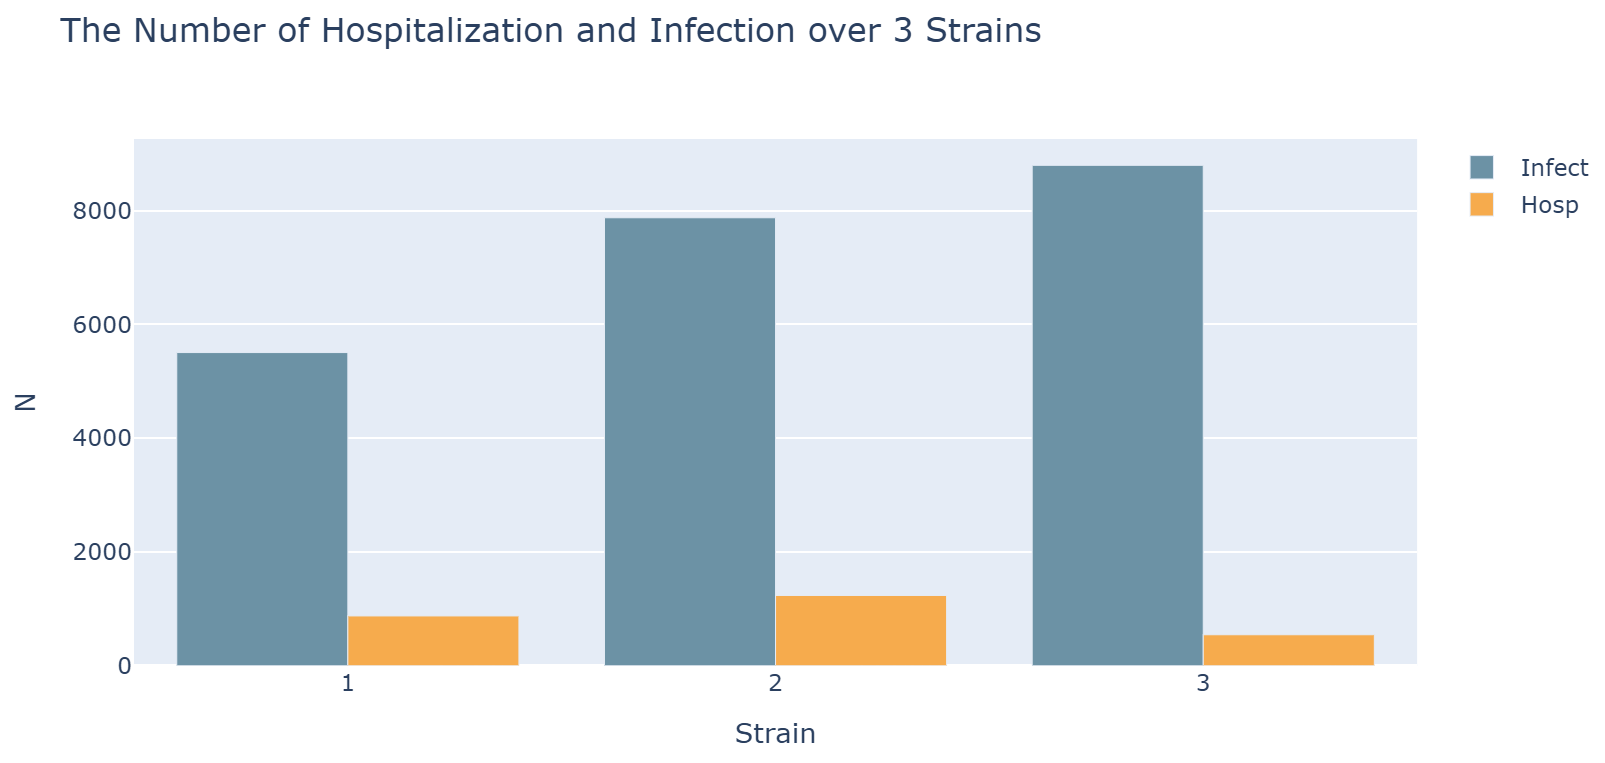